# **实验4: 分类学习实验**

姓名：李昌峻

学号：2023213851

提交要求：每周三20:00前提交，用pdf导出，在学习通上提交pdf文件和ipynb文件，命名方式：学号_实验X。

## 一、实验目标
* 1、了解分类算法的基本原理和应用场景；
* 2、掌握数据预处理和特征选择的技巧；
* 3、熟悉常用的分类算法和Scikit-learn库；
* 4、训练和评估分类模型，提高模型准确率和泛化能力。

## 二、实验步骤
* 1、数据准备：收集并清洗数据，确保数据质量和完整性；
* 2、数据探索：查看数据的分布情况，发现异常值和缺失值，进行必要的数据转换；
* 3、特征工程：通过特征选择、特征构造等方法改善特征质量；
* 4、模型选择：选择合适的分类算法（如决策树、逻辑回归、支持向量机、随机森林等）；
* 5、模型训练：使用Scikit-learn库训练模型，调整超参数以提高性能；
* 6、模型评估：通过交叉验证、混淆矩阵、ROC曲线等手段评估模型性能；
* 7、模型优化：根据评估结果调整模型参数，进一步提高模型性能。


## 1.1 从UCI上下载数据集Iris和Mushroom数据集，保存到文件夹UseData中，然后将UseData中的这两个数据集导入到jupyter notebook中， UCI网址: https://archive.ics.uci.edu/datasets

In [157]:
## 输入代码
# 数据格式修改，从.data到.csv
import pandas as pd
data1 = pd.read_table(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\iris\iris.data')  # 加载本地数据
data1.to_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\iris\iris.csv',sep='|',index=False)  # data转成csv
data2 = pd.read_table(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\mushroom\agaricus-lepiota.data')
data2.to_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\mushroom\agaricus-lepiota.csv',sep='|',index=False)

In [158]:
# 添加列名
Iris = pd.read_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\iris\iris.csv',header=None)
Mushroom = pd.read_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\mushroom\agaricus-lepiota.csv',header=None)
Iris.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class'] # 添加列名
Mushroom.columns = ['poisonous(class)', 'cap shape', 'cap surface', 'cap color', 'bruises', 'odor', 'gill attachment', 'gill spacing', 'gill size', 'gill color', 'stalk shape', 'stalk root', 'stalk surface above ring', 'stalk surface below ring', 'stalk color above ring', 'stalk color below ring','veil type', 'veil color', 'ring number', 'ring type', 'spore print color', 'population', 'habitat'] # 决策类在第一列此时
# print(Iris.head())
# print(Mushroom.head())

In [159]:
import numpy as np
# Mushroom清洗数据
Mushroom.isnull().sum() # 缺失数据集的查看
# 将所有的 "?" 替换为 np.nan
Mushroom.replace("?", np.nan, inplace=True)
Mushroom.isnull().sum()

poisonous(class)               0
cap shape                      0
cap surface                    0
cap color                      0
bruises                        0
odor                           0
gill attachment                0
gill spacing                   0
gill size                      0
gill color                     0
stalk shape                    0
stalk root                  2480
stalk surface above ring       0
stalk surface below ring       0
stalk color above ring         0
stalk color below ring         0
veil type                      0
veil color                     0
ring number                    0
ring type                      0
spore print color              0
population                     0
habitat                        0
dtype: int64

## 1.2 分别输出Iris和Mushroom的对象个数和特征(不包含决策类)个数

In [160]:
## 输入代码
print(Iris.shape[0])
print(Mushroom.shape[0])
print(Iris.shape[1]-1)
print(Mushroom.shape[1]-1)

150
8124
4
22


## 1.3 求决策类的划分，即求每一个决策类所包含的对象，利用字典分别输出Iris和Mushroom的决策类名称和所包含的对象个数

In [161]:
## 输入代码
iris_decision_col = 'class'
mushroom_decision_col = 'poisonous(class)'
iris_class_counts = Iris[iris_decision_col].value_counts().to_dict()
mushroom_class_counts = Mushroom[mushroom_decision_col].value_counts().to_dict()
print(iris_class_counts)
print(mushroom_class_counts)

{'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50}
{'e': 4208, 'p': 3916}


## 2(选做) 你能利用那些方法分析数据的分布

In [162]:
## 输入代码
# 直接查看数据集的描述信息
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'
print(Iris.describe())
print(Mushroom.describe())

       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
       poisonous(class) cap shape cap surface cap color bruises  odor  \
count              8124      8124        8124      8124    8124  8124   
unique                2         6           4        10       2     9   
top                   e         x           y         n       f     n   
freq               4208      3656        3244      2284    4748  3528   

       gill attachment gill spacing gill size gill color  ...  \
count             8124       

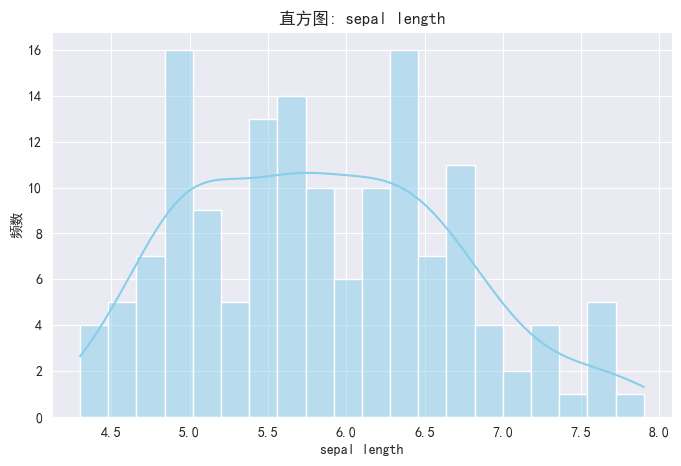

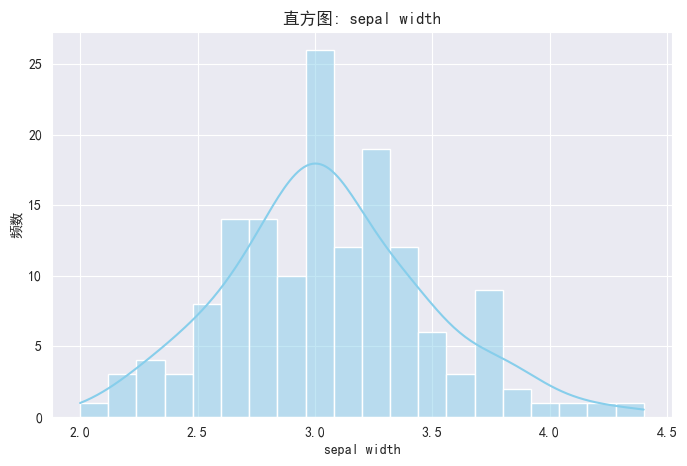

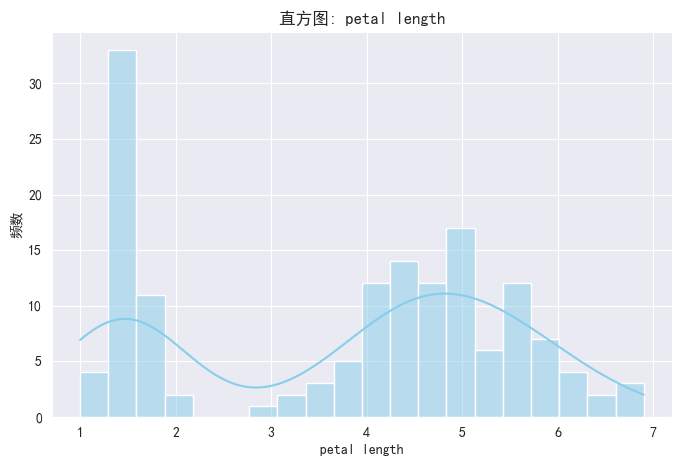

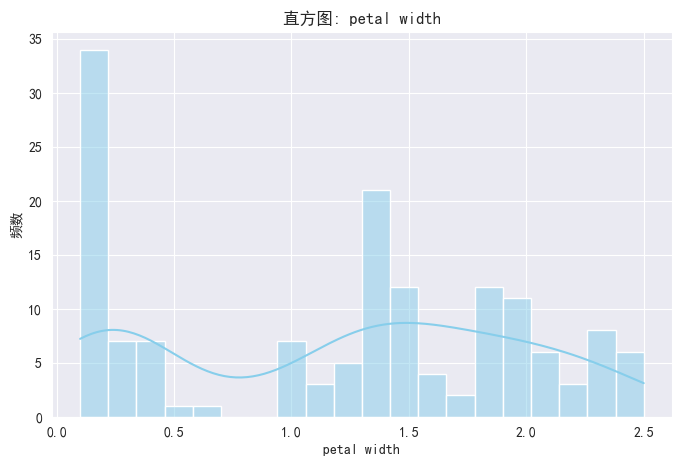

In [163]:
# 分布绘图查看
# 数值型分布直方图查看
Iris.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class'] # 添加列名
for column in Iris.columns[:-1]:  # 排除最后的决策类列
    plt.figure(figsize=(8, 5))
    sns.histplot(Iris[column], kde=True, color='skyblue', bins=20)
    plt.title(f"直方图: {column}")
    plt.xlabel(column)
    plt.ylabel("频数")
    plt.show()

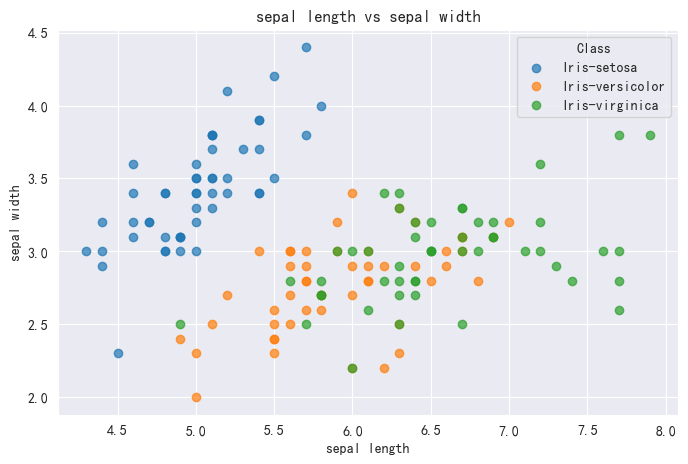

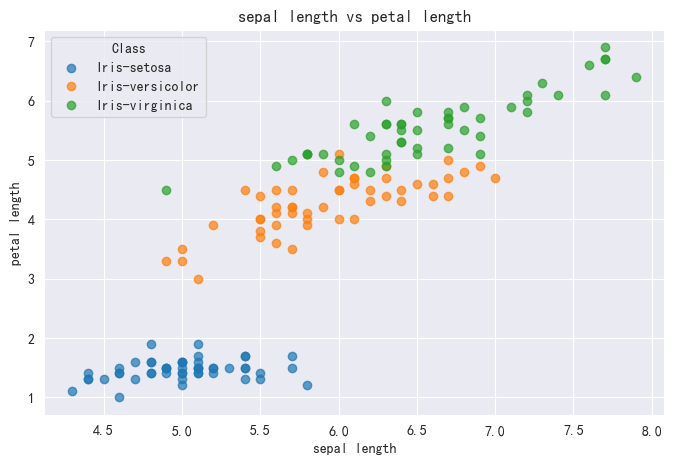

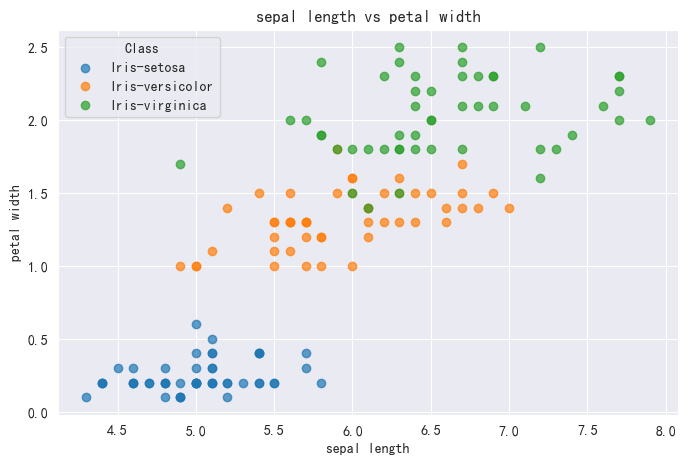

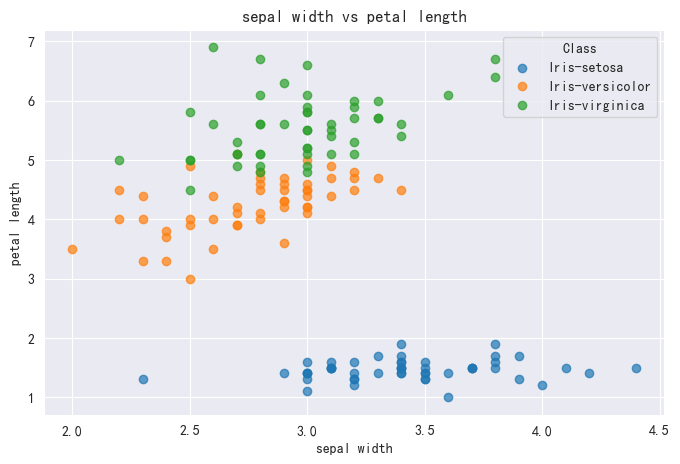

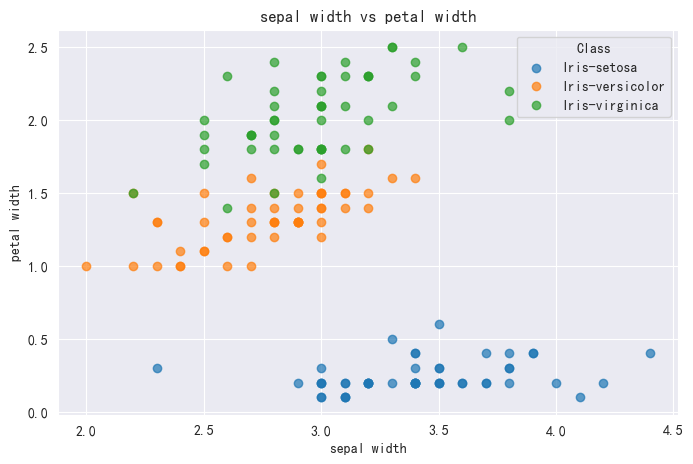

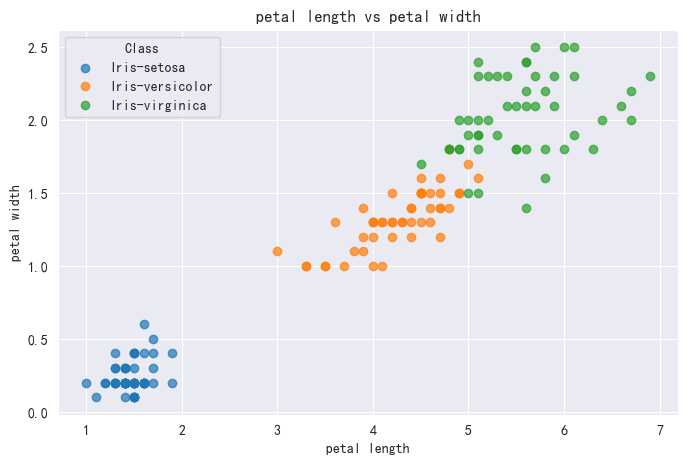

In [164]:
# 选取两两查看散点图
import itertools
features = ['sepal length', 'sepal width', 'petal length', 'petal width']
for feature1, feature2 in itertools.combinations(features, 2):
    plt.figure(figsize=(8, 5))
    for decision_class in Iris['class'].unique():
        subset = Iris[Iris['class'] == decision_class]
        plt.scatter(subset[feature1], subset[feature2], label=decision_class, alpha=0.7)
    plt.title(f"{feature1} vs {feature2}")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.legend(title="Class")
    plt.grid(True)
    plt.show()

## 3.1 利用库函数PCA降维，降维后的特征集记作Red_PCA,用list输出降维后的特征

In [165]:
# 数据清洗
 # 考虑到缺失数据过多，直接删除缺失列
from sklearn.impute import SimpleImputer
Mushroom.replace("?", np.nan, inplace=True)
imputer = SimpleImputer(strategy="most_frequent") #众数填充 精度：
"""
众数填充:
Mushroom 数据集分类结果:
Decision Tree 交叉验证精度: 0.9560
Logistic Regression 交叉验证精度: 0.8944
SVM 交叉验证精度: 0.9177
Random Forest 交叉验证精度: 0.9647
"""
# 对 Mushroom 数据集中的所有列应用填充（假设所有列都有可能包含缺失值）
Mushroom_imputed = pd.DataFrame(imputer.fit_transform(Mushroom))
# 重新给列命名
Mushroom_imputed.columns = Mushroom.columns
Mushroom_imputed.isnull().sum()

# 直接将缺失值的类规定为新的一类用来学习：
Mushroom.isnull().sum()
"""
Mushroom 数据集分类结果:
Decision Tree 交叉验证精度: 0.9567
Logistic Regression 交叉验证精度: 0.9123
SVM 交叉验证精度: 0.9551
Random Forest 交叉验证精度: 0.9651
"""

'\nMushroom 数据集分类结果:\nDecision Tree 交叉验证精度: 0.9567\nLogistic Regression 交叉验证精度: 0.9123\nSVM 交叉验证精度: 0.9551\nRandom Forest 交叉验证精度: 0.9651\n'

In [166]:
# 转化为数值型数据
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# 将每一列的值编码为数字
for col in Mushroom.columns:
    Mushroom[col] = encoder.fit_transform(Mushroom[col])
Mushroom.head()

,poisonous(class),cap shape,cap surface,cap color,bruises,odor,gill attachment,gill spacing,gill size,gill color,...,stalk surface below ring,stalk color above ring,stalk color below ring,veil type,veil color,ring number,ring type,spore print color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [167]:
## 输入代码
from sklearn.decomposition import PCA
iris_feature = Iris.drop(columns=['class'])
pca = PCA(n_components=2)
iris_Red_PCA = pca.fit_transform(iris_feature)
iris_Res_PCA = iris_Red_PCA.tolist()

mushroom_feature = Mushroom.drop(columns=['poisonous(class)'])
pca = PCA(n_components=2)
mushroom_Red_PCA = pca.fit_transform(mushroom_feature)
mushroom_Res_PCA = mushroom_Red_PCA.tolist()
print(iris_Red_PCA)
print(mushroom_Red_PCA)

[[-2.68420713  0.32660731]
 [-2.71539062 -0.16955685]
 [-2.88981954 -0.13734561]
 [-2.7464372  -0.31112432]
 [-2.72859298  0.33392456]
 [-2.27989736  0.74778271]
 [-2.82089068 -0.08210451]
 [-2.62648199  0.17040535]
 [-2.88795857 -0.57079803]
 [-2.67384469 -0.1066917 ]
 [-2.50652679  0.65193501]
 [-2.61314272  0.02152063]
 [-2.78743398 -0.22774019]
 [-3.22520045 -0.50327991]
 [-2.64354322  1.1861949 ]
 [-2.38386932  1.34475434]
 [-2.6225262   0.81808967]
 [-2.64832273  0.31913667]
 [-2.19907796  0.87924409]
 [-2.58734619  0.52047364]
 [-2.3105317   0.39786782]
 [-2.54323491  0.44003175]
 [-3.21585769  0.14161557]
 [-2.30312854  0.10552268]
 [-2.35617109 -0.03120959]
 [-2.50791723 -0.13905634]
 [-2.469056    0.13788731]
 [-2.56239095  0.37468456]
 [-2.63982127  0.31929007]
 [-2.63284791 -0.19007583]
 [-2.58846205 -0.19739308]
 [-2.41007734  0.41808001]
 [-2.64763667  0.81998263]
 [-2.59715948  1.10002193]
 [-2.67384469 -0.1066917 ]
 [-2.86699985  0.0771931 ]
 [-2.62522846  0.60680001]
 

In [168]:
## 3.2(选做) Python还有那些特征选择方法？

In [169]:
## 输入代码

## 4. 利用决策树、逻辑回归、支持向量机、随机森林分别对Iris和Mushroom进行分类，要求输出每一个分类器对每一个数据集的十折交叉精度，

In [170]:
## 输入代码
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Iris数据集的读取
X_iris = Iris.drop(columns=['class'])  # 特征
y_iris = Iris['class']  # 标签
# print(X_iris)
# print(y_iris)

# Mushroom数据集的读取
X_mushroom = Mushroom.iloc[:, 1:]  # 特征
y_mushroom = Mushroom.iloc[:, 0]  # 标签（第一列是决策类）
# print(X_mushroom)
# print(y_mushroom)

# 定义分类器
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "SVM": SVC(decision_function_shape = 'ovo', kernel = 'poly',degree = 7),
    "Random Forest": RandomForestClassifier()
}

def evaluate_model(X, y, classifiers):
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X, y, cv=10, scoring='accuracy')  # 10折交叉验证
        print(f"{clf_name} 交叉验证精度: {scores.mean():.4f}")

print("Iris 数据集分类结果:")
evaluate_model(X_iris, y_iris, classifiers)
print("Mushroom 数据集分类结果:")
evaluate_model(X_mushroom, y_mushroom, classifiers)

Iris 数据集分类结果:
Decision Tree 交叉验证精度: 0.9600
Logistic Regression 交叉验证精度: 0.9733
SVM 交叉验证精度: 0.9533
Random Forest 交叉验证精度: 0.9600
Mushroom 数据集分类结果:
Decision Tree 交叉验证精度: 0.9604
Logistic Regression 交叉验证精度: 0.9123
SVM 交叉验证精度: 0.9551
Random Forest 交叉验证精度: 0.9662


## 5.1 根据实验结果，绘制精度的箱线图，并根据图像解释上述4个算法的优劣

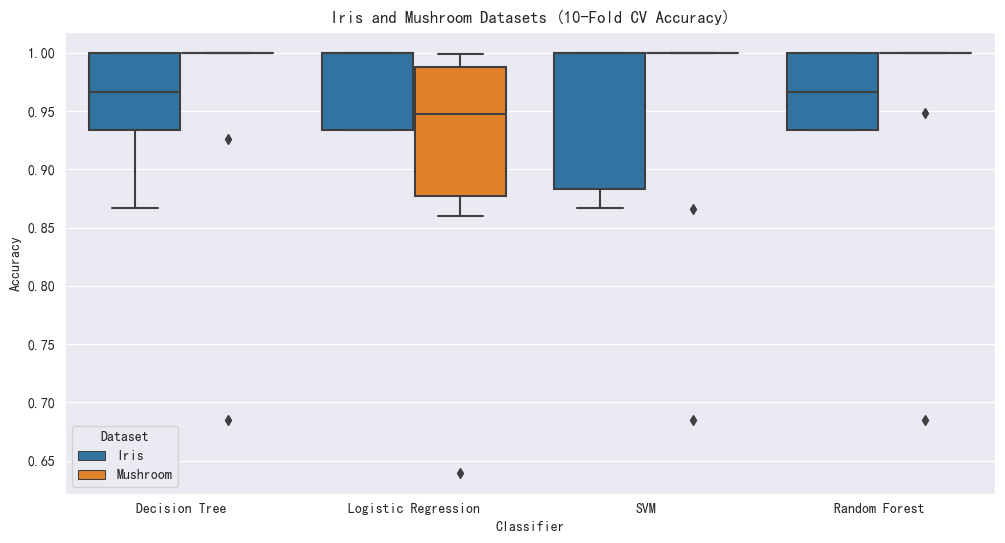

In [171]:
## 输入代码
def collect_scores(X, y, classifiers):
    scores_dict = {clf_name: [] for clf_name in classifiers.keys()}
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X, y, cv=10, scoring='accuracy')  # 10折交叉验证
        scores_dict[clf_name] = scores
    return scores_dict

iris_scores = collect_scores(X_iris, y_iris, classifiers)
mushroom_scores = collect_scores(X_mushroom, y_mushroom, classifiers)

data = []
for clf_name in classifiers.keys():
    # 每个分类器分别处理 Iris 和 Mushroom 的交叉验证结果
    for dataset_name, scores in zip(['Iris', 'Mushroom'], [iris_scores[clf_name], mushroom_scores[clf_name]]):
        for score in scores:
            data.append([clf_name, score, dataset_name])

scores_df = pd.DataFrame(data, columns=['Classifier', 'Accuracy', 'Dataset'])

# 绘制箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='Classifier', y='Accuracy', hue='Dataset', data=scores_df)
plt.title("Iris and Mushroom Datasets (10-Fold CV Accuracy)")
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.show()

## 5.2(选做) 你能利用其他方法分析实验结果？

In [172]:
## 输入代码

## 6 将实验结果(所选的特征、精度等等)保存到Result.csv文件中

In [173]:
## 输入代码
for clf_name in classifiers.keys():
    for dataset_name, scores in zip(['Iris', 'Mushroom'], [iris_scores[clf_name], mushroom_scores[clf_name]]):
        for score in scores:
            # 确保列名为字符串，并加入到 'Selected Features' 中
            if dataset_name == 'Iris':
                selected_features = ', '.join(X_iris.columns)  # Iris
            else:
                selected_features = ', '.join(X_mushroom.columns)  #Mushroom 
            data.append([clf_name, score, dataset_name, selected_features])

scores_df = pd.DataFrame(data, columns=['Classifier', 'Accuracy', 'Dataset', 'Selected Features'])
scores_df.to_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\Result.csv', index=False)
result = pd.read_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\Result.csv')
print(result)
print(result['Selected Features'])

        Classifier  Accuracy   Dataset  \
0    Decision Tree  1.000000      Iris   
1    Decision Tree  0.933333      Iris   
2    Decision Tree  1.000000      Iris   
3    Decision Tree  0.933333      Iris   
4    Decision Tree  0.933333      Iris   
..             ...       ...       ...   
155  Random Forest  1.000000  Mushroom   
156  Random Forest  1.000000  Mushroom   
157  Random Forest  1.000000  Mushroom   
158  Random Forest  0.948276  Mushroom   
159  Random Forest  1.000000  Mushroom   

                                     Selected Features  
0                                                  NaN  
1                                                  NaN  
2                                                  NaN  
3                                                  NaN  
4                                                  NaN  
..                                                 ...  
155  cap shape, cap surface, cap color, bruises, od...  
156  cap shape, cap surface, cap color,

## 7 (选做) 利用XGBoost进行分类实验，并对实验结果进行合理分析与有效展示

In [174]:
print(y_iris)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: object


In [175]:
# 原始数据保留? 直接转化为nan
Mushroom_origin = pd.read_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\UseData\mushroom\agaricus-lepiota.csv',header=None)
Mushroom_origin.columns = ['poisonous(class)', 'cap shape', 'cap surface', 'cap color', 'bruises', 'odor', 'gill attachment', 'gill spacing', 'gill size', 'gill color', 'stalk shape', 'stalk root', 'stalk surface above ring', 'stalk surface below ring', 'stalk color above ring', 'stalk color below ring','veil type', 'veil color', 'ring number', 'ring type', 'spore print color', 'population', 'habitat']
Mushroom_origin.replace("?", np.nan, inplace=True)
label_encoder = LabelEncoder()
for column in Mushroom_origin.columns:
    if Mushroom_origin[column].isnull().any():
        # 非缺失值进行编码
        Mushroom_origin[column] = Mushroom_origin[column].apply(lambda x: label_encoder.fit_transform([x])[0] if pd.notnull(x) else np.nan)
    else:
        Mushroom_origin[column] = label_encoder.fit_transform(Mushroom_origin[column])

Mushroom_origin.isnull().sum()
X_mushroom_origin = Mushroom_origin.drop(columns=['poisonous(class)'])
y_mushroom_origin = Mushroom_origin['poisonous(class)']

In [176]:
# 调参
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

X_train, X_test, y_train, y_test = train_test_split(X_mushroom_origin, y_mushroom_origin, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(eval_metric='mlogloss')
# 定义超参数空间
param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': [0, 1, 5]
}

random_search = RandomizedSearchCV(estimator=xgb_classifier, param_distributions=param_dist, n_iter=100, cv=3, n_jobs=-1, scoring='accuracy', verbose=1, random_state=42)


random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
y_pred = random_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'colsample_bytree': 0.6872700594236812, 'gamma': 0, 'learning_rate': 0.06503043695984914, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 0.5780093202212182}
Test Accuracy: 1.0000


[0.68511685 1.         1.         1.         1.         1.
 1.         1.         0.97044335 1.        ]


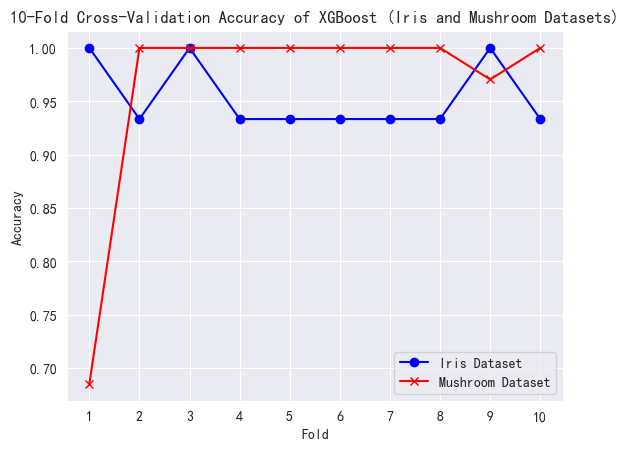

In [177]:
import xgboost as xgb

xgb_classifier = xgb.XGBClassifier(eval_metric='mlogloss', n_estimators=100)

# iris的y转化为0，1，2
label_encoder = LabelEncoder()
y_iris_encoded = label_encoder.fit_transform(y_iris)

def collect_xgb_scores(X, y):
    return cross_val_score(xgb_classifier, X, y, cv=10, scoring='accuracy')

iris_xgb_scores = collect_xgb_scores(X_iris, y_iris_encoded)
mushroom_xgb_scores = collect_xgb_scores(X_mushroom_origin, y_mushroom_origin)
print(mushroom_xgb_scores)

data = []
for dataset_name, scores in zip(['Iris', 'Mushroom_origin'], [iris_xgb_scores, mushroom_xgb_scores]):
    for score in scores:
        selected_features = ', '.join(X_iris.columns if dataset_name == 'Iris' else X_mushroom_origin.columns)
        data.append(['XGBoost', score, dataset_name, selected_features])
        
scores_df = pd.DataFrame(data, columns=['Classifier', 'Accuracy', 'Dataset', 'Selected Features'])

scores_df.to_csv(r'C:\Users\李昌峻\Desktop\实验课\No4\Result_XGBoost.csv', index=False)

plt.plot(range(1, 11), iris_xgb_scores, marker='o', linestyle='-', color='b', label='Iris Dataset')
plt.plot(range(1, 11), mushroom_xgb_scores, marker='x', linestyle='-', color='r', label='Mushroom Dataset')
plt.title("10-Fold Cross-Validation Accuracy of XGBoost (Iris and Mushroom Datasets)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(np.arange(1, 11, 1))
plt.legend()
plt.show()